In [41]:
!pip install nltk wordcloud

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [43]:
import pandas as pd
import csv

df = pd.read_csv(
    "Hotel_Reviews.csv",
    engine="python",
    quoting=csv.QUOTE_MINIMAL,
    on_bad_lines="skip"
)

print(df.shape)
df.head()

(1017970, 17)


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [44]:
print(df.shape)

(1017970, 17)


In [45]:
df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [46]:
df.columns

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='object')

In [47]:
df.isnull().sum()

,0
Hotel_Address,0
Additional_Number_of_Scoring,1
Review_Date,4
Average_Score,5
Hotel_Name,9
Reviewer_Nationality,13
Negative_Review,18
Review_Total_Negative_Word_Counts,23
Total_Number_of_Reviews,43
Positive_Review,49


In [48]:
df["Review"] = df["Positive_Review"] + " " + df["Negative_Review"]

In [49]:
df["Review"].head()

,Review
0,Only the park outside of the hotel was beauti...
1,No real complaints the hotel was great great ...
2,Location was good and staff were ok It is cut...
3,Great location in nice surroundings the bar a...
4,Amazing location and building Romantic settin...


In [50]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [51]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [52]:
df["Clean_Review"] = df["Review"].apply(clean_text)

In [53]:
!pip install textblob

In [54]:
from textblob import TextBlob

In [55]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [57]:
df["Sentiment"] = df["Clean_Review"].apply(get_sentiment)

In [58]:
df[["Clean_Review","Sentiment"]].head()

,Clean_Review,Sentiment
0,park outside hotel beautiful angry made post a...,Positive
1,real complaint hotel great great location surr...,Positive
2,location good staff ok cute hotel breakfast ra...,Positive
3,great location nice surroundings bar restauran...,Positive
4,amazing location building romantic setting boo...,Positive


In [59]:
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,822934
Negative,144373
Neutral,50663


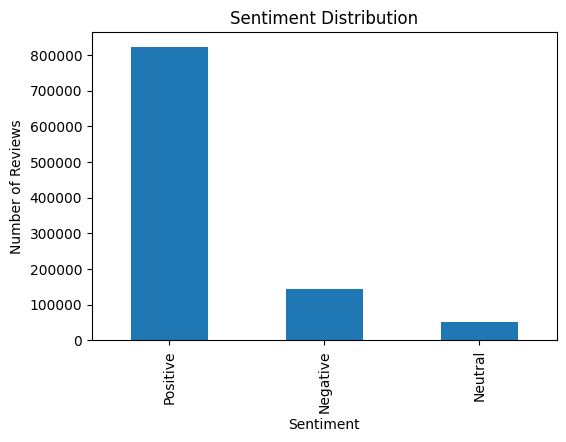

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [61]:
keywords = [
    "staff",
    "room",
    "food",
    "location",
    "clean",
    "service",
    "wifi",
    "bed",
    "bathroom",
    "breakfast"
]

In [62]:
issue_count = {}

for word in keywords:
    issue_count[word] = df["Clean_Review"].str.contains(word).sum()

issue_count

{'staff': np.int64(427693),
 'room': np.int64(544578),
 'food': np.int64(52356),
 'location': np.int64(391102),
 'clean': np.int64(178057),
 'service': np.int64(86390),
 'wifi': np.int64(36768),
 'bed': np.int64(197470),
 'bathroom': np.int64(84941),
 'breakfast': np.int64(253486)}

In [63]:
issue_df = pd.DataFrame(
    issue_count.items(),
    columns=["Issue","Frequency"]
)

issue_df

,Issue,Frequency
0,staff,427693
1,room,544578
2,food,52356
3,location,391102
4,clean,178057
5,service,86390
6,wifi,36768
7,bed,197470
8,bathroom,84941
9,breakfast,253486


In [64]:
issue_df = issue_df.sort_values(
    by="Frequency",
    ascending=False
)

issue_df

,Issue,Frequency
1,room,544578
0,staff,427693
3,location,391102
9,breakfast,253486
7,bed,197470
4,clean,178057
5,service,86390
8,bathroom,84941
2,food,52356
6,wifi,36768


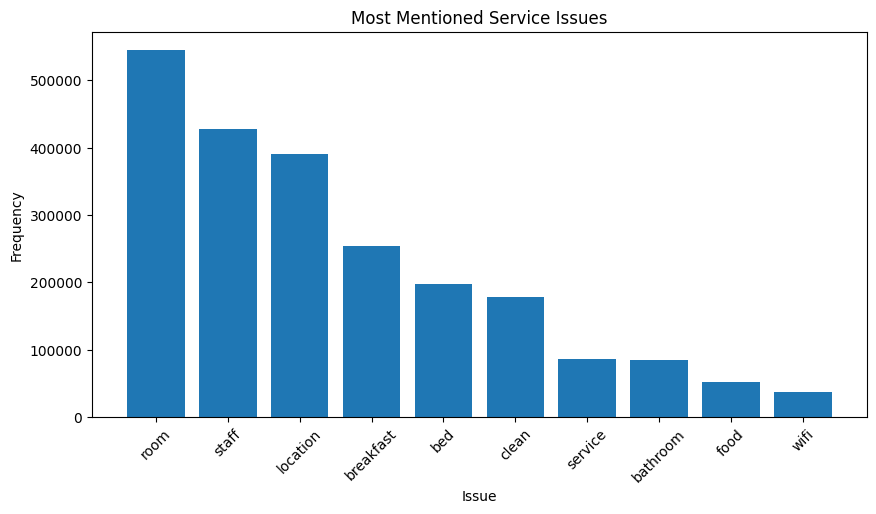

In [65]:
plt.figure(figsize=(10,5))

plt.bar(issue_df["Issue"], issue_df["Frequency"])

plt.title("Most Mentioned Service Issues")
plt.xlabel("Issue")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [66]:
sentiment_percent = (
    df["Sentiment"]
    .value_counts(normalize=True)
    *100
)

print(sentiment_percent)

Sentiment
Positive    80.840693
Negative    14.182442
Neutral      4.976866
Name: proportion, dtype: float64


In [67]:
print("Hotel Review Analysis Report")
print("----------------------------")

print("Total Reviews:", len(df))

print("\nSentiment Distribution")
print(df["Sentiment"].value_counts())

print("\nTop Service Issues")
print(issue_df.head())

Hotel Review Analysis Report
----------------------------
Total Reviews: 1017970

Sentiment Distribution
Sentiment
Positive    822934
Negative    144373
Neutral      50663
Name: count, dtype: int64

Top Service Issues
       Issue  Frequency
1       room     544578
0      staff     427693
3   location     391102
9  breakfast     253486
7        bed     197470


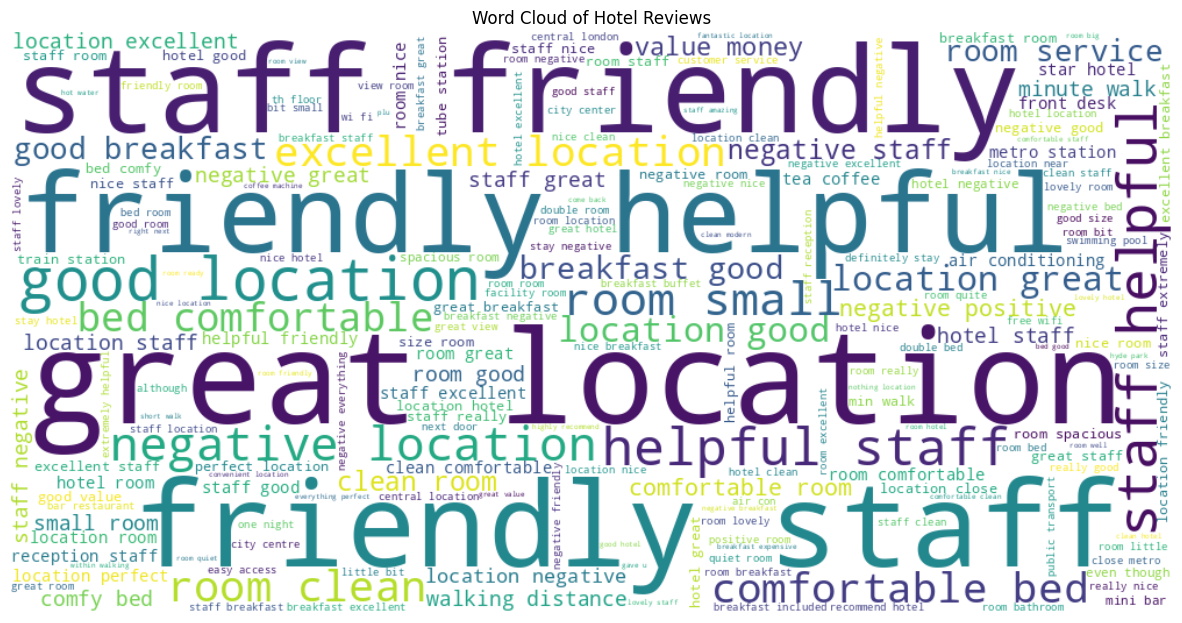

In [68]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["Clean_Review"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Hotel Reviews")
plt.show()

In [69]:
print("="*50)
print("HOTEL REVIEW ANALYSIS REPORT")
print("="*50)

print(f"\nTotal Reviews: {len(df)}")

print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())

print("\nSentiment Percentage:")
print((df["Sentiment"].value_counts(normalize=True) * 100).round(2))

print("\nTop 5 Service Issues:")
print(issue_df.head())

print("\nProject Completed Successfully!")

HOTEL REVIEW ANALYSIS REPORT

Total Reviews: 1017970

Sentiment Distribution:
Sentiment
Positive    822934
Negative    144373
Neutral      50663
Name: count, dtype: int64

Sentiment Percentage:
Sentiment
Positive    80.84
Negative    14.18
Neutral      4.98
Name: proportion, dtype: float64

Top 5 Service Issues:
       Issue  Frequency
1       room     544578
0      staff     427693
3   location     391102
9  breakfast     253486
7        bed     197470

Project Completed Successfully!


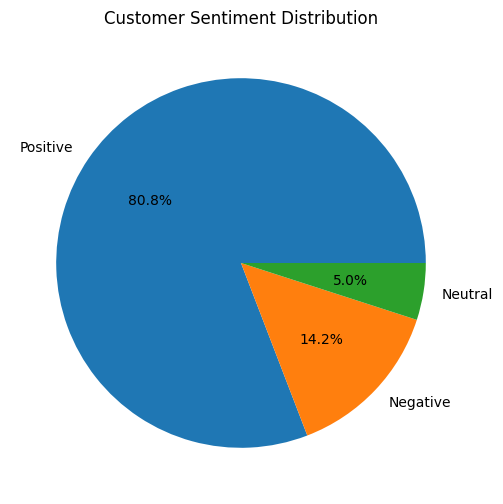

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Sentiment Distribution")
plt.ylabel("")
plt.show()

## Conclusion

This project successfully analyzed hotel customer reviews using Natural Language Processing (NLP). The reviews were collected, preprocessed, and classified into positive, negative, and neutral sentiments. Frequently mentioned service aspects such as staff, rooms, cleanliness, food, and location were identified. Visualizations including sentiment charts and a word cloud helped summarize customer opinions. The analysis provides useful insights that can help hotel management improve service quality and customer satisfaction.